## Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    Callback
)

import joblib

## Load Dataset

In [2]:
df = pd.read_csv("dataset_sigaleh_Final.csv")

## Sort Time Series

In [3]:
df['Tanggal'] = pd.to_datetime(df['Tanggal'])

df = df.sort_values(
    by=['Wilayah', 'Komoditas (Rp)', 'Tanggal']
)

df = df.reset_index(drop=True)

## Handle Missing Value

In [4]:
df = df.ffill()

## Feature Engineering:

### Harga Kemarin

In [5]:
df['Harga_Kemarin'] = df.groupby(
    ['Wilayah', 'Komoditas (Rp)']
)['Harga'].shift(1)

### Harga Minggu Lalu

In [6]:
df['Harga_Minggu_Lalu'] = df.groupby(
    ['Wilayah', 'Komoditas (Rp)']
)['Harga'].shift(7)

### Lag 14

In [7]:
df['Lag_14'] = df.groupby(
    ['Wilayah', 'Komoditas (Rp)']
)['Harga'].shift(14)

### Rolling Mean 7 Hari

In [8]:
df['Rolling_Mean_7'] = df.groupby(
    ['Wilayah', 'Komoditas (Rp)']
)['Harga'].transform(
    lambda x: x.rolling(7).mean()
)

### Rolling Std 7 Hari

In [9]:
df['Rolling_Std_7'] = df.groupby(
    ['Wilayah', 'Komoditas (Rp)']
)['Harga'].transform(
    lambda x: x.rolling(7).std()
)

### Price Change

In [10]:
df['Price_Change'] = df.groupby(
    ['Wilayah', 'Komoditas (Rp)']
)['Harga'].pct_change()

## Drop Missing akibat Lag

In [11]:
df = df.dropna().reset_index(drop=True)

## Encoding

In [12]:
commodity_encoder = LabelEncoder()
city_encoder = LabelEncoder()

df['commodity_encoded'] = commodity_encoder.fit_transform(
    df['Komoditas (Rp)']
)

df['city_encoded'] = city_encoder.fit_transform(
    df['Wilayah']
)

## Feature Time

In [13]:
df['Bulan'] = df['Tanggal'].dt.month
df['Hari'] = df['Tanggal'].dt.dayofweek

## Fitur

In [14]:
features = [
    'Harga',
    'Suhu_Rata2_C',
    'Curah_Hujan_mm',
    'Harga_Kemarin',
    'Harga_Minggu_Lalu',
    'Lag_14',
    'Rolling_Mean_7',
    'Rolling_Std_7',
    'Price_Change',
    'commodity_encoded',
    'city_encoded',
    'Bulan',
    'Hari'
]

## Scaling

In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df[features]
)

## Sliding Window

In [16]:
window_size = 14

X = []
y = []

for i in range(window_size, len(scaled_data)):

    X.append(
        scaled_data[i-window_size:i]
    )

    y.append(
        scaled_data[i, 0]
    )

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(90524, 14, 13)
(90524,)


## Split Data

In [17]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

## Model LSTM

In [18]:
input_layer = Input(
    shape=(
        X_train.shape[1],
        X_train.shape[2]
    )
)

x = LSTM(
    64,
    return_sequences=True
)(input_layer)

x = Dropout(0.2)(x)

x = LSTM(32)(x)

x = Dense(
    32,
    activation='relu'
)(x)

output = Dense(1)(x)

model = Model(
    inputs=input_layer,
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 14, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 14, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,473 (130.75 KB)

 Trainable params: 33,473 (130.75 KB)

 Non-trainable params: 0 (0.00 B)

## Callback

In [19]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.0001
)


class CustomCallback(Callback):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        print(
            f"Epoch {epoch+1} | "
            f"Loss: {logs['loss']:.4f} | "
            f"Val: {logs['val_loss']:.4f}"
        )

## Training

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.2,
    callbacks=[
        early_stop,
        reduce_lr,
        CustomCallback()
    ]
)

Epoch 1/60
1810/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0013 - mae: 0.0192Epoch 1 | Loss: 0.0006 | Val: 0.0008
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - loss: 6.3523e-04 - mae: 0.0143 - val_loss: 8.2545e-04 - val_mae: 0.0162 - learning_rate: 0.0010
Epoch 2/60
1809/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.9893e-04 - mae: 0.0100Epoch 2 | Loss: 0.0003 | Val: 0.0005
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - loss: 3.1047e-04 - mae: 0.0098 - val_loss: 5.0864e-04 - val_mae: 0.0118 - learning_rate: 0.0010
Epoch 3/60
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2.3131e-04 - mae: 0.0086Epoch 3 | Loss: 0.0002 | Val: 0.0005
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - loss: 2.4735e-04 - mae: 0.0085 - val_loss: 4.7194e-04 - val_mae: 0.0134 - learning_rate: 0.0010
Epoch 4/60
1809/1811 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.7086e-04 - mae: 0.0073Epoch 4 | Loss: 0.0002 | Val: 0.0007
1811/1811 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step - loss: 1.9660e-04 - mae: 0.0074 -

## Prediction

In [21]:
pred = model.predict(X_test)

566/566 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


## Inverse Scaling

In [22]:
harga_min = scaler.data_min_[0]
harga_max = scaler.data_max_[0]

pred_inv = (
    pred * (harga_max - harga_min)
) + harga_min

y_test_inv = (
    y_test.reshape(-1,1)
    * (harga_max - harga_min)
) + harga_min

## Evaluation:

### RMSE

In [23]:
rmse = np.sqrt(
    mean_squared_error(
        y_test_inv,
        pred_inv
    )
)

print(f"RMSE : {rmse:.2f}")

RMSE : 1966.28


### MAE

In [24]:
mae = mean_absolute_error(
    y_test_inv,
    pred_inv
)

print(f"MAE : {mae:.2f}")

MAE : 833.77


### MAPE

In [25]:
mape = np.mean(
    np.abs(
        (y_test_inv - pred_inv)
        / y_test_inv
    )
) * 100

print(f"MAPE : {mape:.2f}%")

MAPE : 1.33%


## Accuracy Forecasting

In [26]:
accuracy = 100 - mape

print(f"Accuracy : {accuracy:.2f}%")

Accuracy : 98.67%


## Visualization

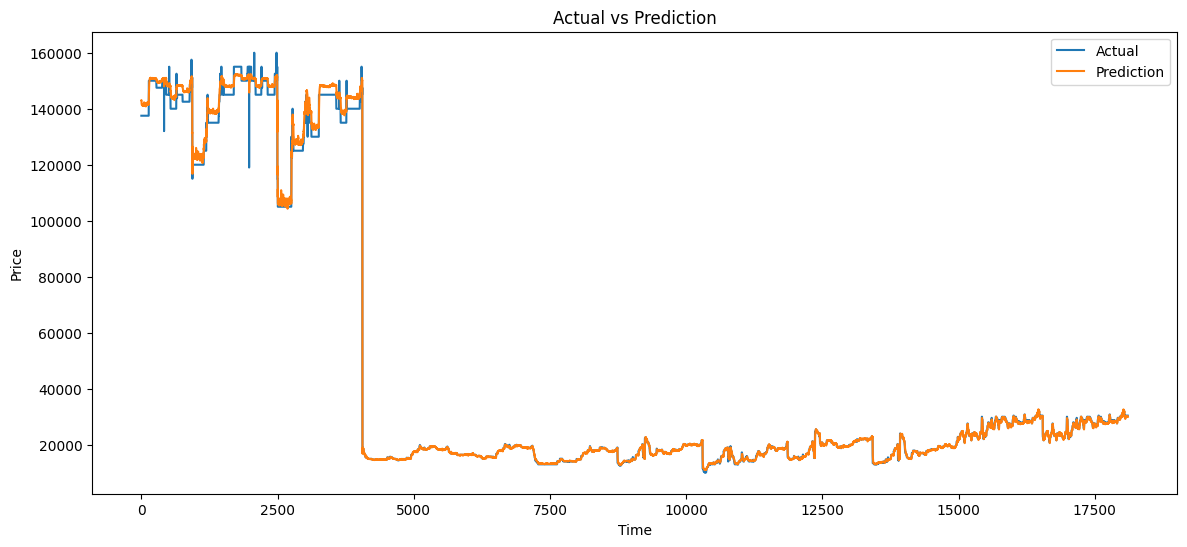

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_inv,
    label='Actual'
)

plt.plot(
    pred_inv,
    label='Prediction'
)

plt.title(
    'Actual vs Prediction'
)

plt.xlabel('Time')
plt.ylabel('Price')

plt.legend()

plt.show()

## Save Model

In [28]:
model.save(
    "model_lstm.keras" #savedmodel, pb, h5, onnx
)

## Save Scaler

In [31]:
joblib.dump(
    scaler,
    "scaler.save" # joblib atau pkl
)

['scaler.save']

## Save Encoder

In [30]:
joblib.dump(
    commodity_encoder,
    "commodity_encoder.save"
)

joblib.dump(
    city_encoder,
    "city_encoder.save"
)

['city_encoder.save']